# Exercises

In [1]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import fetch_openml

# Fetch the MNIST dataset
mnist = fetch_openml("mnist_784", as_frame=False)

In [2]:
X, y = mnist.data, mnist.target.astype(int)

In [3]:
print(f"""
MNIST Dataset Size: {len(X)}
MNIST Output Size: {len(y)}
""")


MNIST Dataset Size: 70000
MNIST Output Size: 70000



Separate out your test set. Since the dataset is already pre-shuffled. We can split it as it.

NOTE: don't be stupid like me in the code below. I made the mistake of missing a zero and including only 6000 samples in the training set
which impacted by accuracy at the end. Check your zeroes people!

In [4]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### Question 1:
Try to build a classifier from the MNSIT dataset that achieves over 97% accuracy on the test set. Hint: the `KNeighborsClassifier`works quite well for the task; you just need to find good hyperparameter values (try grid search on the `weights` and `n_neighbors` hyperparameter)

**Solution:** As part of this question we need to
1. Create a classifier
2. Experiment with the hyperparameters using grid search
3. Evaluate the model
4. Measure it against the test set to check if we have reached the expected accuracy.

I'm just doing a simple run here to play around with the model. This isn't actually what the question is asking for, just doing it to
get warmed up. See further down for the exact answer.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

kn_classifier = KNeighborsClassifier()
kn_scores = cross_val_score(kn_classifier, X_train, y_train, cv=3)
kn_scores

array([0.9676 , 0.9671 , 0.96755])

Without any tuning on our part, the model scores > 90%. What do the model's precision and recall look like? We should visualize it to get a better idea, before we calculate the scores.

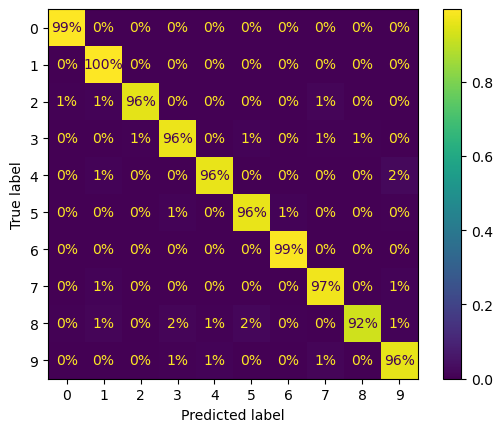

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

kn_predictions = cross_val_predict(kn_classifier, X_train, y_train, cv=4)
ConfusionMatrixDisplay.from_predictions(y_train, kn_predictions, normalize="true", values_format=".0%")
plt.show()

Like we did in the chapter, the error distribution might give us a better idea of what our model is bad with. We can see that by filtering out all the things the model got correct as we did
in the chapter.

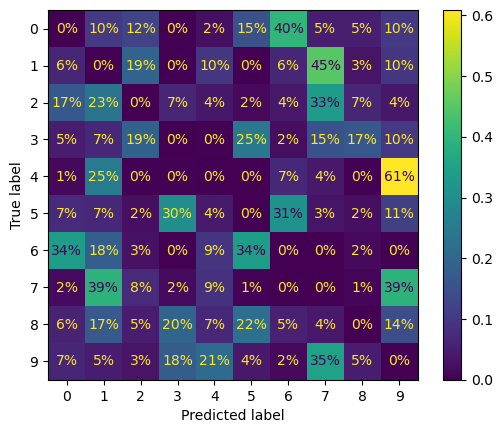

In [7]:
ConfusionMatrixDisplay.from_predictions(y_train, kn_predictions, 
                                        sample_weight=(kn_predictions != y_train), 
                                        normalize="true", values_format=".0%")
plt.show()

Look's like it has a terrible time with 4s and confuses them with 9s. I wonder if rotating the digits via augumentation will make a difference
to this error - maybe we can check that a little later.

In [8]:
# Quick look at the default model scores.
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# QQQ: What is precision? what is recall? What is f1? What is the roc curve and what does the auc represent? 
# QQQ: What are their formulas? What does each score mean?
kn_default_precision = precision_score(y_train, kn_predictions, average="macro")
kn_default_recall = recall_score(y_train, kn_predictions, average="macro")
kn_default_f1 = f1_score(y_train, kn_predictions, average="macro")

kn_decision_function = cross_val_predict(kn_classifier, X_train, y_train, cv=4, method="predict_proba")
kn_default_roc_auc = roc_auc_score(y_train, kn_decision_function, average="macro", multi_class='ovr')

print(f'''
Precision: {kn_default_precision}
Recall: {kn_default_recall}
F1 Score: {kn_default_f1}
ROC Area under the Curve Score: {kn_default_roc_auc}
''')


Precision: 0.9689045782897218
Recall: 0.9679371548176784
F1 Score: 0.9682301426701978
ROC Area under the Curve Score: 0.9949076433790938



We've played with the model a good amount. Now let's try to solve the actual problem. We can grid search over possible hyperparameters to see how our model performs with each
of them.

In [9]:
from sklearn.model_selection import GridSearchCV

grid_params = {
    "weights": ["uniform", "distance"],
    "n_neighbors": [0, 1, 3, 4, 5, 6, 7, 9]
}
# Since the question asks for 97% accuracy we will use the accuracy as a scoring metric of the GridSearch.
kn_gs = GridSearchCV(kn_classifier, grid_params, scoring="accuracy", cv=4)

In [10]:
%%time
# Just a warning: this cell takes quite a bit of time to run.
# You can probably reduce it by reducing 'cv' and the number of parameter combinations in the previous cell.
kn_gs.fit(X_train, y_train)

CPU times: user 30min 13s, sys: 34.5 s, total: 30min 47s
Wall time: 3min 19s


GridSearchCV(cv=4, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [0, 1, 3, 4, 5, 6, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [11]:
import pandas as pd

results_df = pd.DataFrame(data=kn_gs.cv_results_)
(results_df[["rank_test_score", "mean_test_score", "std_test_score", "param_weights", "param_n_neighbors"]]
 .sort_values(["rank_test_score"], ascending=True))

,rank_test_score,mean_test_score,std_test_score,param_weights,param_n_neighbors
7,1,0.971317,0.000589,distance,4
11,2,0.970717,0.000709,distance,6
5,3,0.970467,0.000688,distance,3
9,4,0.969700,0.000881,distance,5
4,5,0.969433,0.000657,uniform,3
2,6,0.968500,0.000803,uniform,1
3,6,0.968500,0.000803,distance,1
8,8,0.968417,0.000884,uniform,5
13,9,0.968300,0.000657,distance,7
6,10,0.968100,0.000907,uniform,4


Took its time, and with the best arguments we are indeed getting an accuracy that is above 97% Yay!

Doesn't look like it made much of a difference to the 4s being classified wrongly as 9s.

**NOTE**: Remember, this is on the training set.

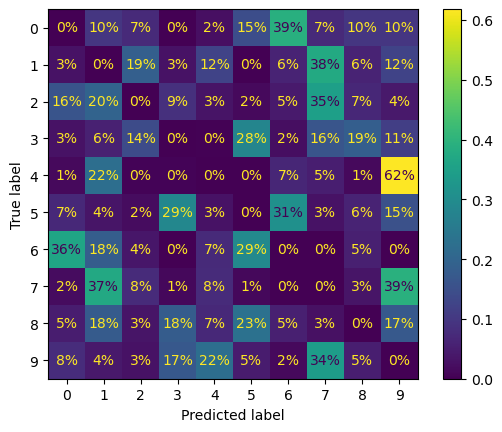

In [12]:
kn_classifier_best = kn_gs.best_estimator_
kn_predictions_best = cross_val_predict(kn_classifier_best, X_train, y_train, cv=4)
ConfusionMatrixDisplay.from_predictions(y_train, kn_predictions_best, normalize="true",
                                        sample_weight=(kn_predictions_best != y_train),
                                        values_format=".0%")
plt.show()

In [13]:
from sklearn.metrics import accuracy_score
kn_best_predictions = kn_classifier_best.predict(X_test)

accuracy_score(y_test, kn_best_predictions)

0.9714

Awesome! We did it!

### Question 2:
Write a function that can shift an MNIST image in any direction (left, right, up, or down) by one pixel. Then, for each image in
(one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your  model performs
even better now! This technique of artificially growing the training set is called *data augmentation* or *training set expansion*.

In [14]:
# As hinted in the book: we can use the shift function from scipy to achieve this.
from scipy.ndimage.interpolation import shift

def shift_image(image_to_shift, direction="left"):
    img = image_to_shift.reshape(28, 28)
    if direction == "left":
        return shift(img, [0, -1])
    elif direction == "right":
        return shift(img, [0, 1])
    elif direction == "up":
        return shift(img, [-1, 0])
    elif direction == "down":
        return shift(img, [1, 0])
    else:
        print('Specify a valid direction: ["left", "right", "up", "down"]')

def shift_in_all_directions(image_to_shift):
    return [
            shift_image(image_to_shift, direction="left"),
            shift_image(image_to_shift, direction="right"),
            shift_image(image_to_shift, direction="up"),
            shift_image(image_to_shift, direction="down")
    ]

def print_shifted_images(shifted_images):
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(1, 4)
        
    # Iterate over the axes and images
    for ax, img , label in zip(axes.flat, shifted_images, ["left", "right", "up", "down"]):
        ax.imshow(img, cmap='binary')
        ax.set_title(label)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

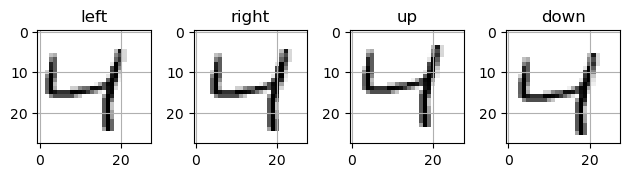

In [15]:
import matplotlib.pyplot as plt
import numpy as np

image_to_shift = X_train[2]
shifted_images = shift_in_all_directions(image_to_shift)

print_shifted_images(shifted_images)

In [16]:
X_augumented = []
y_augumented = []

for i in range(0, len(X_train)):
    X_augumented += shift_in_all_directions(X_train[i])
    y_augumented += 4 * [y_train[i]]

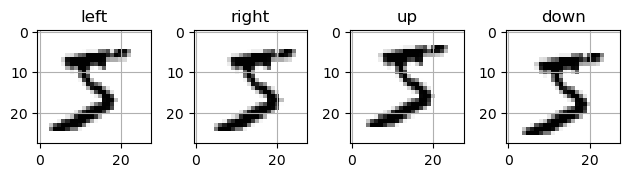

In [17]:
print_shifted_images(X_augumented[:4])

In [18]:
X_augumented = [np.asarray(xaug).reshape(784,) for xaug in X_augumented]

In [19]:
# QQQ: When is a model fit vs refit? i.e. I trained it once on part of the dataset now I have another part that I want to train it on. But I don't want to reset it.
kn_classifier_best.fit(X_augumented, y_augumented)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [20]:
kn_best_predictions = kn_classifier_best.predict(X_test)

accuracy_score(y_test, kn_best_predictions)

0.9743

We did get a small improvement compared to the unaugumented data. Interestingly, the number of 1s being confused as other numbers have
decreased, and whatever errors we have left seem to be happening against 1st and 9s, additionally, as before, we still see the confusion with
4s and 9s.

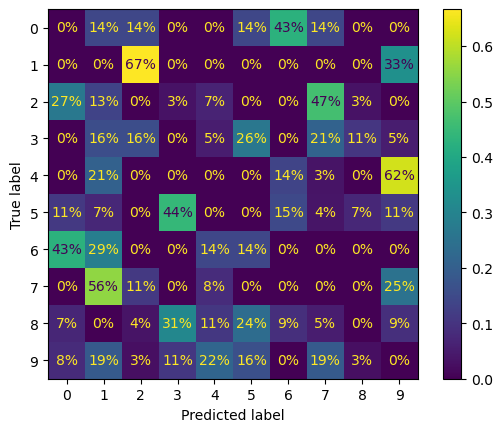

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, kn_best_predictions, normalize="true",
                                        sample_weight=(kn_best_predictions != y_test),
                                        values_format=".0%")
plt.show()

### Question 3:
Tackle the Titanic dataset. A great place to start is on Kaggle(https://kaggle.com/c/titanic). Alternatively, you can download the data from https://homl.info/titanic/titanic.tgz and unzip this tarball like you did 
for the housing data in Chapter 2. This will give you two CSV files, train.csv and test.csv, which you can load using `pandas.read_csv()`. The goal is to train a classifier that can predict the `Survived` column based
on the other columns

In [22]:
import pandas as pd
# I have downloaded the dataset from kaggle and put it in a folder ch3
# the code below assumes that the folder ch3 is in the same folder as notebook
train = pd.read_csv("./ch3/train.csv")
test = pd.read_csv("./ch3/test.csv")
gender_submission = pd.read_csv("./ch3/gender_submission.csv")

Lookign at the data we have below, I just jotted down some initial thoughts about the attributes we have.
- **PassengerId**: This looks like a unique identifier for the passengers, so don't think this will help us much.
- **Survived**: We need to separate this out as our target
- **Pclass**: The passenger classes, 1st, 2nd, and 3rd. Probably an indicator of how well-off the people are, and might provide interesting insight into the survivorship.
- **Name**: - While the name itself might not be a useful value, perhaps it can be used to dervice additional features e.g. identifying who was in a family together, their relationships etc.
- **Sex**: definitely going to be super helpful. But since this is a categorical attribute we might need to hot encode this, or convert it into a simple 1 and 0
- **Age**: This too would have been a useful indicator, however, I looked into the ages more and it looks like the age is missing for a large number of our datapoints. Can we reliably replace these? Too many of them are missing, I'm more inclined to drop this column.
- **SibSp**: Singlings and spouses. Once again useful for verifying family, not sure if it is useful to use raw. Calculating a correlation matrix for them might help.
- **Parch**: parents and children aboard the titanic. Same as SibSp
- **Ticket**: Not sure how helpful this is, it just looks like a bunch of strings with no pattern (on first glance at least)
- **Fare**: How much money was spent by the passenger. Question: How does this show for groups?
- **Cabin**: It follows the patter 'Alphabet+Number', perhaps if we can split these up, the letter can give us a group e.g. berth class etc, while the number might indicate the location on the floor.
- **Embarked**: Not sure if death discriminates by who got on where, but the correlation matrix should help us figure that out.

In [23]:
print(f"Size of training.csv: {len(train)}")
train.head()

Size of training.csv: 891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We have a test set here. We can use this to test our model at the end. **NOTE**: there target class doesn't exist in the below test set.
This is because we will have to upload our prediction results onto kaggle to get our score. The `gender_submission.csv` is the format
in which it expects the output to be uploaded.

In [24]:
print(f"Size of test.csv: {len(test)}")
test.head()

Size of test.csv: 418


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [25]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


#### Data Exploration
Let's look further into the data and see if we can identify any gaps or opportunities to improve out predictive power.

In [26]:
data_set = train.copy()
data_set.columns = ["passenger_id", "survived", "p_class", "name", "sex", "age", "siblings_and_spouses", "parents_and_children", "ticket", "fare", "cabin", "embarked"]

In [27]:
data_set.dtypes

passenger_id              int64
survived                  int64
p_class                   int64
name                     object
sex                      object
age                     float64
siblings_and_spouses      int64
parents_and_children      int64
ticket                   object
fare                    float64
cabin                    object
embarked                 object
dtype: object

In [28]:
data_set.describe()

,passenger_id,survived,p_class,age,siblings_and_spouses,parents_and_children,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Our target class has two possible values as we would expect.

In [29]:
print(f'Unique values for survived: {data_set["survived"].unique()}')
print(f'Unique values for p_class: {data_set["p_class"].unique()}')
print(f'Unique values for sex: {data_set["sex"].unique()}. However, {len(data_set[data_set["sex"].isna()])}/{len(data_set)} of the rows have empty values for sex.''')
print(f'''We have about {len(data_set["age"].unique())} unique values for age. However, {len(data_set[data_set["age"].isna()])}/{len(data_set)} of the rows have empty values for age.''')
print(f'Unique values for embarked: {data_set["embarked"].unique()}. However, {len(data_set[data_set["embarked"].isna()])}/{len(data_set)} of the rows have empty values for embarked.')

Unique values for survived: [0 1]
Unique values for p_class: [3 1 2]
Unique values for sex: ['male' 'female']. However, 0/891 of the rows have empty values for sex.
We have about 89 unique values for age. However, 177/891 of the rows have empty values for age.
Unique values for embarked: ['S' 'C' 'Q' nan]. However, 2/891 of the rows have empty values for embarked.


The cabin, ticket and name classes are a little free text. So let's look at them one by one and see if we can find anything useful.

In [30]:
print(f'{len(data_set[data_set["cabin"].isna()])}/{len(data_set)} of rows have empty values for cabin')
print(f'Unique values for {data_set["cabin"].unique()}')

687/891 of rows have empty values for cabin
Unique values for [nan 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33'
 'B30' 'C52' 'B28' 'C83' 'F33' 'F G73' 'E31' 'A5' 'D10 D12' 'D26' 'C110'
 'B58 B60' 'E101' 'F E69' 'D47' 'B86' 'F2' 'C2' 'E33' 'B19' 'A7' 'C49'
 'F4' 'A32' 'B4' 'B80' 'A31' 'D36' 'D15' 'C93' 'C78' 'D35' 'C87' 'B77'
 'E67' 'B94' 'C125' 'C99' 'C118' 'D7' 'A19' 'B49' 'D' 'C22 C26' 'C106'
 'C65' 'E36' 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'B18' 'C124' 'C91'
 'E40' 'T' 'C128' 'D37' 'B35' 'E50' 'C82' 'B96 B98' 'E10' 'E44' 'A34'
 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'A14' 'B37' 'C30' 'D20' 'B79'
 'E25' 'D46' 'B73' 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'C101' 'C68'
 'A10' 'E68' 'B41' 'A20' 'D19' 'D50' 'D9' 'A23' 'B50' 'A26' 'D48' 'E58'
 'C126' 'B71' 'B51 B53 B55' 'D49' 'B5' 'B20' 'F G63' 'C62 C64' 'E24' 'C90'
 'C45' 'E8' 'B101' 'D45' 'C46' 'D30' 'E121' 'D11' 'E77' 'F38' 'B3' 'D6'
 'B82 B84' 'D17' 'A36' 'B102' 'B69' 'E49' 'C47' 'D28' 'E17' 'A24' 'C

In [31]:
data_set[data_set["embarked"] == "Q"][["embarked", "p_class", "ticket", "cabin"]]

,embarked,p_class,ticket,cabin
5,Q,3,330877,NaN
16,Q,3,382652,NaN
22,Q,3,330923,NaN
28,Q,3,330959,NaN
32,Q,3,335677,NaN
...,...,...,...,...
790,Q,3,12460,NaN
825,Q,3,368323,NaN
828,Q,3,367228,NaN
885,Q,3,382652,NaN


In [32]:
data_set.groupby(by="ticket").count().sort_values("passenger_id", ascending=False)

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,fare,cabin,embarked
ticket,,,,,,,,,,,
1601,7,7,7,7,7,4,7,7,7,0,7
CA. 2343,7,7,7,7,7,0,7,7,7,0,7
347082,7,7,7,7,7,7,7,7,7,0,7
CA 2144,6,6,6,6,6,6,6,6,6,0,6
347088,6,6,6,6,6,6,6,6,6,0,6
...,...,...,...,...,...,...,...,...,...,...,...
345572,1,1,1,1,1,1,1,1,1,0,1
345364,1,1,1,1,1,1,1,1,1,0,1
343276,1,1,1,1,1,1,1,1,1,0,1


As we can see below, a group doesn't need to be related only by family or last name to be considered a group. I wonder if the younger
ladies below might be assistants to the countess. They don't seem to share any titles.

In [33]:
data_set[data_set["ticket"] == '110152']

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5,B77,S
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5,B79,S
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,B77,S


In [34]:
data_set[data_set["ticket"] == 'W./C. 6608']

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked
86,87,0,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.375,NaN,S
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.375,NaN,S
436,437,0,3,"Ford, Miss. Doolina Margaret ""Daisy""",female,21.0,2,2,W./C. 6608,34.375,NaN,S
736,737,0,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.375,NaN,S


In [35]:
data_set[data_set["ticket"] == 'CA 2144']

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S
386,387,0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S
683,684,0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,NaN,S


In [36]:
data_set[data_set["ticket"] == '110465']

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked
110,111,0,1,"Porter, Mr. Walter Chamberlain",male,47.0,0,0,110465,52.0,C110,S
475,476,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0,A14,S


In [37]:
data_set[data_set["age"].isna() & (data_set["parents_and_children"] <= 2) & (data_set["parents_and_children"] > 0)]

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked
65,66,1,3,"Moubarek, Master. Gerios",male,NaN,1,1,2661,15.2458,NaN,C
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C
140,141,0,3,"Boulos, Mrs. Joseph (Sultana)",female,NaN,0,2,2678,15.2458,NaN,C
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,NaN,0,1,113505,55.0000,E33,S
176,177,0,3,"Lefebre, Master. Henry Forbes",male,NaN,3,1,4133,25.4667,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.5500,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.5500,NaN,S
229,230,0,3,"Lefebre, Miss. Mathilde",female,NaN,3,1,4133,25.4667,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.5500,NaN,S


After a look at the above data, here are my thoughts:
- Perhaps we can identify families and based on the `siblings_and_spouses`, `parents_and_children`, and `name` attributes identify who 
are the children and who are the parents. This allows us to:
    - Impute the age based on the class of children rather than the whole dataset.
    - Identify a separate `parent/adult` and `child` class which might be helpful.
- We can dervice a `group_size` parameter based on `siblings_and_spouses`, `parents_and_children` and `tickets` parameter.
Maybe the `cabin` attribute can help us with this too.
- For the final dataset on which we will do prediction, I don't think we can include the `cabin` attribute as too many rows are missing it. However, there might still be hope, once we group by family and ticket maybe we can deduce the cabins based on the group. In such a situation, I would like to split the `cabin` attribute into two attributes
    - The alphabet: which can perhaps tell us which floor/region the cabin might have been in e.g. A, B, C
    - The numeral: which can perhaps tell us where on that floor/region that cabin is located e.g. C 01, C 02 etc.

We might do all of the above, or none of the above. But before we do that, let's try running the data through a simple model with minimum processing. 

#### Simple test: minimal processing and a first try with `KNeighborsClassifier` and `DecisionTreeClassifier`

In [38]:
X_simple = train.copy()
X_simple.columns = ["passenger_id", "survived", "p_class", "name", "sex", "age", "siblings_and_spouses", "parents_and_children", "ticket", "fare", "cabin", "embarked"]

y_simple = X_simple["survived"].to_list()
X_simple = X_simple.drop(columns=["passenger_id", "survived", "name", "ticket", "cabin", "age"])

In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)
default = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

simple_transformer = ColumnTransformer([
    ("categorical", cat_pipeline, ["sex", "embarked"])
], remainder=default)

In [40]:
processed_data = simple_transformer.fit_transform(X_simple)
X_simple = pd.DataFrame(processed_data, columns=simple_transformer.get_feature_names_out())

X_simple

,categorical__sex_female,categorical__sex_male,categorical__embarked_C,categorical__embarked_Q,categorical__embarked_S,remainder__p_class,remainder__siblings_and_spouses,remainder__parents_and_children,remainder__fare
0,0.0,1.0,0.0,0.0,1.0,0.827377,0.432793,-0.473674,-0.502445
1,1.0,0.0,1.0,0.0,0.0,-1.566107,0.432793,-0.473674,0.786845
2,1.0,0.0,0.0,0.0,1.0,0.827377,-0.474545,-0.473674,-0.488854
3,1.0,0.0,0.0,0.0,1.0,-1.566107,0.432793,-0.473674,0.420730
4,0.0,1.0,0.0,0.0,1.0,0.827377,-0.474545,-0.473674,-0.486337
...,...,...,...,...,...,...,...,...,...
886,0.0,1.0,0.0,0.0,1.0,-0.369365,-0.474545,-0.473674,-0.386671
887,1.0,0.0,0.0,0.0,1.0,-1.566107,-0.474545,-0.473674,-0.044381
888,1.0,0.0,0.0,0.0,1.0,0.827377,0.432793,2.008933,-0.176263
889,0.0,1.0,1.0,0.0,0.0,-1.566107,-0.474545,-0.473674,-0.044381


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

kn_classifier = KNeighborsClassifier()
kn_predictions = cross_val_predict(kn_classifier, X_simple, y_simple, cv=3)
cross_val_score(kn_classifier, X_simple, y_simple, cv=3)

array([0.77104377, 0.7979798 , 0.7979798 ])

In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_predictions = cross_val_predict(dt_classifier, X_simple, y_simple, cv=3)
cross_val_score(dt_classifier, X_simple, y_simple, cv=4)

array([0.7264574 , 0.84753363, 0.83856502, 0.81081081])

Not bad! This is just for us to get a sense of the data. But these scores can be misleading, lets check with our
precision and recall scores.

In [43]:
def calculate_scores(y, predictions):
    return {
        "precision": precision_score(y, predictions, average="macro"),
        "recall": recall_score(y, predictions, average="macro"),
        "f1": f1_score(y, predictions, average="macro")
    }

In [44]:
simple_kn_scores = calculate_scores(y_simple, kn_predictions)
simple_kn_scores

{'precision': 0.7783685420315236,
 'recall': 0.7708992426421244,
 'f1': 0.7740774708675011}

In [45]:
simple_dt_scores = calculate_scores(y_simple, dt_predictions)
simple_dt_scores

{'precision': 0.7676767676767677,
 'recall': 0.7515099223468507,
 'f1': 0.7572363313740712}

#### Data Preparation

Based on the basic analysis we did above, let's see if can identify groups in our dataset of 891 passengers. We can identify groups based on a few attributes:
- The names of the passengers (it is likely that those with similar last names are in the same group/family)
- Ticket (those with the same ticket would mostly be in the same group.)
- cabin (is is likely that those in similar cabins might be in the same group, this isn't necessary though. Two single travellers could share the same cabin)

In [46]:
data_set[['last_name', 'first_name']] = data_set['name'].str.split(',', n=1, expand=True)
data_set['group_size_by_family'] = data_set.groupby('last_name')['name'].transform('size')

In [47]:
(data_set[['survived', 'first_name', 'last_name', 'group_size_by_family', 'ticket', 'cabin', 'embarked', 'siblings_and_spouses', 'parents_and_children']]
.sort_values(by='group_size_by_family', ascending=False)[:20])

,survived,first_name,last_name,group_size_by_family,ticket,cabin,embarked,siblings_and_spouses,parents_and_children
146,1,"Mr. August Edvard (""Wennerstrom"")",Andersson,9,350043,NaN,S,0,0
68,1,Miss. Erna Alexandra,Andersson,9,3101281,NaN,S,4,2
610,0,Mrs. Anders Johan (Alfrida Konstantia Brogren),Andersson,9,347082,NaN,S,1,5
119,0,Miss. Ellis Anna Maria,Andersson,9,347082,NaN,S,4,2
813,0,Miss. Ebba Iris Alfrida,Andersson,9,347082,NaN,S,4,2
850,0,Master. Sigvard Harald Elias,Andersson,9,347082,NaN,S,4,2
542,0,Miss. Sigrid Elisabeth,Andersson,9,347082,NaN,S,4,2
13,0,Mr. Anders Johan,Andersson,9,347082,NaN,S,1,5
541,0,Miss. Ingeborg Constanzia,Andersson,9,347082,NaN,S,4,2
792,0,Miss. Stella Anna,Sage,7,CA. 2343,NaN,S,8,2


The above should give us the group sizes. I wonder if the families themselves can be considered as individual classes, i.e. a 
correlation between family and survival (just a thought).

Now, let's check based on the tickets. We have no rows that are missing tickets (the man obviously exacted his toll) so hopefully this will be helpful.

In [48]:
print(f'{len(data_set[data_set["ticket"].isna()])}/{len(data_set)} of rows have empty values for ticket')

0/891 of rows have empty values for ticket


In [49]:
data_set['group_size_by_ticket'] = data_set.groupby('ticket')['name'].transform('size')
(data_set[['survived', 'first_name', 'last_name', 'group_size_by_family', 'group_size_by_ticket', 'ticket', 'cabin', 'embarked']]
.sort_values(by='group_size_by_family', ascending=False)[:20])

,survived,first_name,last_name,group_size_by_family,group_size_by_ticket,ticket,cabin,embarked
146,1,"Mr. August Edvard (""Wennerstrom"")",Andersson,9,1,350043,NaN,S
68,1,Miss. Erna Alexandra,Andersson,9,1,3101281,NaN,S
610,0,Mrs. Anders Johan (Alfrida Konstantia Brogren),Andersson,9,7,347082,NaN,S
119,0,Miss. Ellis Anna Maria,Andersson,9,7,347082,NaN,S
813,0,Miss. Ebba Iris Alfrida,Andersson,9,7,347082,NaN,S
850,0,Master. Sigvard Harald Elias,Andersson,9,7,347082,NaN,S
542,0,Miss. Sigrid Elisabeth,Andersson,9,7,347082,NaN,S
13,0,Mr. Anders Johan,Andersson,9,7,347082,NaN,S
541,0,Miss. Ingeborg Constanzia,Andersson,9,7,347082,NaN,S
792,0,Miss. Stella Anna,Sage,7,7,CA. 2343,NaN,S


In [50]:
(data_set[data_set['group_size_by_ticket'] != data_set['group_size_by_family']]
 .sort_values(by='group_size_by_family', ascending=False))

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked,last_name,first_name,group_size_by_family,group_size_by_ticket
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S,Andersson,Master. Sigvard Harald Elias,9,7
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.2750,NaN,S,Andersson,Miss. Sigrid Elisabeth,9,7
146,147,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S,Andersson,"Mr. August Edvard (""Wennerstrom"")",9,1
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S,Andersson,Mr. Anders Johan,9,7
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S,Andersson,Miss. Ellis Anna Maria,9,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C,Ringhini,Mr. Sante,1,3
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C,Bidois,Miss. Rosalie,1,4
689,690,1,1,"Madill, Miss. Georgette Alexandra",female,15.0,0,1,24160,211.3375,B5,S,Madill,Miss. Georgette Alexandra,1,3
681,682,1,1,"Hassab, Mr. Hammad",male,27.0,0,0,PC 17572,76.7292,D49,C,Hassab,Mr. Hammad,1,3


In [51]:
data_set[data_set["ticket"] == 'PC 17760']

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked,last_name,first_name,group_size_by_family,group_size_by_ticket
269,270,1,1,"Bissette, Miss. Amelia",female,35.0,0,0,PC 17760,135.6333,C99,S,Bissette,Miss. Amelia,1,3
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C,Young,Miss. Marie Grice,1,3
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C,Ringhini,Mr. Sante,1,3


- Both trying to identify groups by their `last_name` and then by their `tickets` has their own downsides. We end up with two distinct
meanings of what a group is.
- One group is a family who share a history, are related to one another, and might thus advantage the survival of their own.
- The other groups shares a ticket/room I assume and so their survivorship might be tied to the proximity of their groups to survival
opportunities and risks i.e. exits, lifeboats, flooded compartments etc.
- Then there is off course the intersection of both groups: same family and same ticket.
- Let's see how we can put this to use.

Reader, I know you migth think I am overthinking this - but let me live, this is fun :D

Now coming to the cabins, let's see if we can fill in the details of those who are missing cabins.

If all else fails, perhaps we can mark them as unknowns.

In [52]:
print(f'{len(data_set[data_set["cabin"] == ''])}/{len(data_set)} of rows have empty values for cabin')
data_set['cabin'] = data_set['cabin'].fillna('')
data_set['concatenated_cabin'] = data_set.groupby('ticket')['cabin'].transform(lambda c: ','.join(sorted(set(c))))
data_set['concatenated_cabin_by_family'] = data_set.groupby('last_name')['cabin'].transform(lambda c: ','.join(sorted(set(c))))

print(f'{len(data_set[data_set["concatenated_cabin"] == ''])}/{len(data_set)} of rows have empty values for cabin after grouping by ticket')
print(f'{len(data_set[data_set["concatenated_cabin_by_family"] == ''])}/{len(data_set)} of rows have empty values for cabin after grouping by ticket')

0/891 of rows have empty values for cabin
676/891 of rows have empty values for cabin after grouping by ticket
667/891 of rows have empty values for cabin after grouping by ticket


Though we do make some gains, they aren't substantial. Not all is lost though:
- We can mark the rows without cabin with a placeholder value that indicates an unknown
- We can drop the column completely too now that we know it doesn't have informaton for all the rows.
- Here I prefer grouping by ticket, because when we do so by family, it is clear that we exlude groups that have the same rooms. So
even if we don't know their cabin, we most likely know that they are together and can handle them as such.

All of the above are efforts by us to fill in information - we could be totally wrong about it too, but we will play around and see what
happens.

Another attribute that would help us a bunch if we had all of it is `age`. However, we see that we have 177 rows that do not have values for age, which is quite a bummer as that would be a strong indicator (I think, as we have a natural inclination to protect the young).

Is there anything we can do about it? Let's see.

In [53]:
data_set[data_set["age"].isna()]

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked,last_name,first_name,group_size_by_family,group_size_by_ticket,concatenated_cabin,concatenated_cabin_by_family
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,,Q,Moran,Mr. James,3,1,,
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,,S,Williams,Mr. Charles Eugene,4,1,,
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,,C,Masselmani,Mrs. Fatima,1,1,,
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,,C,Emir,Mr. Farred Chehab,1,1,,
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,,Q,O'Dwyer,"Miss. Ellen ""Nellie""",1,1,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,,C,Razi,Mr. Raihed,1,1,,
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,,S,Sage,"Miss. Dorothy Edith ""Dolly""",7,7,,
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,,S,van Melkebeke,Mr. Philemon,1,1,,
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,,S,Laleff,Mr. Kristo,1,1,,


While typing the above, I had a bad feeling that we migt have to just calculate the mean or median, but that would be very inaccurate.
Halfway through the thought, I realized that we could use an imputer and assign ages bassed on a regression model using attributes that
might be similar between the passenger.

We did something similar in chapter 1 with the housing prices. Hopefully that makes a difference.

#### The pipeline

In [54]:
data_set.dtypes

passenger_id                      int64
survived                          int64
p_class                           int64
name                             object
sex                              object
age                             float64
siblings_and_spouses              int64
parents_and_children              int64
ticket                           object
fare                            float64
cabin                            object
embarked                         object
last_name                        object
first_name                       object
group_size_by_family              int64
group_size_by_ticket              int64
concatenated_cabin               object
concatenated_cabin_by_family     object
dtype: object

Having looked through our data, what do we want to do now?
- Since survived is the target, we are going to separate that out from our input
- We are going to drop the following columns: `passenger_id`, `ticket`, `cabin`, `group_size_by_family`, `oncatenated_cabin`, and `concatenated_cabin`.
- We will `name`, `last_name`, and `first_name` to impute the `age` of passengers with missing ages.
- We will one-hot-encode all our categorical attributes
- We will scale all our numerical attributes
- `embarked` as two rows with values missing, we will assign them median values or see if we can assign them based values based on the ticket patterns.

In [55]:
data = data_set.copy().drop(["survived", "passenger_id", "cabin", 'concatenated_cabin', 'group_size_by_ticket',
                             'concatenated_cabin', 'concatenated_cabin_by_family', "ticket"], axis=1)
y = data_set["survived"]

In [56]:
data.head()

,p_class,name,sex,age,siblings_and_spouses,parents_and_children,fare,embarked,last_name,first_name,group_size_by_family
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Braund,Mr. Owen Harris,2
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Heikkinen,Miss. Laina,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),2
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Allen,Mr. William Henry,2


In [57]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [58]:
data["title"] = data["first_name"].str.split('.').str[0].str.strip()
data.loc[data["title"] == "Miss", "title"] = "Ms"
data = data.drop(["name", "last_name", "first_name"], axis=1)

print(f"Unique titles: {data["title"].unique().tolist()}")

Unique titles: ['Mr', 'Mrs', 'Ms', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess', 'Jonkheer']


In [59]:
numerical_attributes = data.select_dtypes(include=["int64", "float64"]).columns.to_list()
numerical_attributes.remove('p_class')
categorical_attributes = data.select_dtypes('object').columns.to_list() + ['p_class']

print(f"Numerical Columns: {numerical_attributes}")
print(f"Categorical Columns: {categorical_attributes}")

Numerical Columns: ['age', 'siblings_and_spouses', 'parents_and_children', 'fare', 'group_size_by_family']
Categorical Columns: ['sex', 'embarked', 'title', 'p_class']


In [60]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Categorical pipeline to impute and one-hot-encode our categorical attributes
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder()
)
# Numerical pipeline to standardize our numerical inputs
numerical_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)
# We have to handle age a little differently as we have to impute it with a similarity Imputer.
age_pipeline = make_pipeline(
    KNNImputer(n_neighbors=2),
    StandardScaler()
)

In [61]:
from sklearn.preprocessing import LabelEncoder

preprocessing = ColumnTransformer([
    ("categorical", categorical_pipeline, ['sex', 'embarked', 'p_class']),
    ("numerical", numerical_pipeline, ['siblings_and_spouses', 'parents_and_children', 'fare', 'group_size_by_family']),
    ("age", age_pipeline, ["age"])
])

In [62]:
processed_data = preprocessing.fit_transform(data)
processed_df = pd.DataFrame(processed_data, columns=preprocessing.get_feature_names_out())
processed_df

,categorical__sex_female,categorical__sex_male,categorical__embarked_C,categorical__embarked_Q,categorical__embarked_S,categorical__p_class_1,categorical__p_class_2,categorical__p_class_3,numerical__siblings_and_spouses,numerical__parents_and_children,numerical__fare,numerical__group_size_by_family,age__age
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.432793,-0.473674,-0.502445,0.079241,-0.592481
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.432793,-0.473674,0.786845,-0.593173,0.638789
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.474545,-0.473674,-0.488854,-0.593173,-0.284663
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.432793,-0.473674,0.420730,0.079241,0.407926
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.474545,-0.473674,-0.486337,0.079241,0.407926
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.474545,-0.473674,-0.386671,-0.593173,-0.207709
887,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.474545,-0.473674,-0.044381,0.751655,-0.823344
888,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.432793,2.008933,-0.176263,0.079241,0.000000
889,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.474545,-0.473674,-0.044381,-0.593173,-0.284663


In [63]:
kn_pipeline = make_pipeline(preprocessing, KNeighborsClassifier())
kn_pipeline = make_pipeline(preprocessing, DecisionTreeClassifier())

#### Train
Earlier we did default runs with two models. Let's try running them on the data set now post processing.

In [64]:
kn_classifier = KNeighborsClassifier()
kn_predictions = cross_val_predict(kn_classifier, processed_data, y, cv=3)
cross_val_score(kn_classifier, processed_data, y, cv=3)

array([0.77104377, 0.8013468 , 0.7979798 ])

In [65]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_predictions = cross_val_predict(dt_classifier, processed_data, y, cv=3)
cross_val_score(dt_classifier, processed_data, y, cv=3)

array([0.73400673, 0.7979798 , 0.75084175])

In [66]:
calculate_scores(y, kn_predictions)

{'precision': 0.7806325534981705,
 'recall': 0.769605023487681,
 'f1': 0.773998049473914}

In [67]:
calculate_scores(y, dt_predictions)

{'precision': 0.7477325251820521,
 'recall': 0.742066915923689,
 'f1': 0.7445049508282794}

In [68]:
simple_kn_scores

{'precision': 0.7783685420315236,
 'recall': 0.7708992426421244,
 'f1': 0.7740774708675011}

In [69]:
simple_dt_scores

{'precision': 0.7676767676767677,
 'recall': 0.7515099223468507,
 'f1': 0.7572363313740712}

Yikes! Looks like we actually did worse in terms of the score.

In [70]:
processed_df["age__age"].unique()

array([-0.5924806 ,  0.63878901, -0.2846632 ,  0.40792596,  0.        ,
        1.87005862, -2.13156761, -0.20770885, -1.20811541, -1.97765891,
        2.17787603, -0.7463893 ,  0.71574336,  1.94701297,  0.10010856,
        0.33097161, -1.13116105, -0.1307545 , -1.66984151, -0.82334365,
        0.79269771,  2.79351083,  0.94660642, -0.66943495, -0.900298  ,
       -2.05461326, -1.74679586,  1.48528687, -0.05380014,  2.71655648,
       -0.09227732, -1.90070456, -1.43897846,  1.17746947, -0.97725235,
        0.17706291, -1.0542067 , -0.36161755, -2.2216042 ,  0.02315421,
        0.25401726, -0.51552625, -0.4385719 ,  1.25442382,  2.25483038,
        3.17828259,  0.56183466,  1.33137817, -1.16963823,  3.13980541,
        0.21554008, -1.36202411, -1.59288716,  0.52335749,  1.63919557,
        1.98549015,  0.83117489,  1.10051512, -2.20852197,  2.40873908,
        2.02396733,  1.56224122,  0.48488031,  1.21594664, -0.70791213,
        2.48569343,  0.86965206,  1.71614992,  2.56264778, -0.47